XGBoost - CPCV and walk-forward validation:

1. First use CPCV to find optimal hyperparameters.
2. Then validate the model with walk-forward.

Cotributions:
1. Lpoez de Prado - Advances in ML for Finance
2. https://blog.quantinsti.com/cross-validation-embargo-purging-combinatorial/

In [65]:
# Import libraries:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib import pyplot as plt
from tqdm import tqdm
import os
import joblib
from sklearn.model_selection import BaseCrossValidator
from itertools import combinations
from collections import defaultdict
from sklearn.model_selection import ParameterGrid

In [66]:
# Import data:
# run script from the data_input file
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("momentum_labeled.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','trend_bin']]    # trend_bin = trend label
df_factor = df_factor.set_index('Date')

df_curve = pd.read_csv("top50_features.csv", parse_dates=['Date'])
df_curve = df_curve.set_index('Date')


#df_additional = pd.read_csv("additional_features.csv", parse_dates=['Date'])
#df_additional = df_additional.set_index('Date')  

#df_features = pd.concat([df_curve,df_additional], axis=1, join='inner')
#df_features = df_features.fillna(df_features.mean()) 


data = pd.concat([df_curve,df_factor], axis=1, join='inner')
data = data.dropna()

print(data.columns)

Index(['Momentum_excess_momentum_lag1', 'Momentum_vs_Value_trend_lag1',
       'Value_vs_Quality_Cumulative_lag1', 'Quality_momentum_24M_lag1',
       'Momentum_vs_Quality_trend_lag1', 'Momentum_relative_kurtosis_lag1',
       'Momentum_lag1', 'Momentum_relative_skewness_lag1',
       'Momentum_vs_Quality_lag1', 'Momentum_momentum_1M_lag1',
       'Quality_relative_skewness_lag1', 'Value_vs_Quality_trend_lag1',
       'SA_NB_Slope_QS_lag1', 'SA_NB_Curvature_QS_lag1', 'SA_NB_Slope_TS_lag1',
       'US_NB_Curvature_QS_lag1', 'Value_momentum_12M_lag1',
       'SA_NB_Level_lag1', 'Value_excess_volatility_lag1',
       'SA_NB_Curvature_lag1', 'Quality_momentum_12M_lag1',
       'Value_relative_kurtosis_lag1', 'SA_NB_Level_QS_lag1',
       'Value_relative_volatility_lag1', 'Momentum_momentum_6M_lag1',
       'Momentum_excess_kurtosis_lag1', 'US_NB_Level_QS_lag1',
       'US_NB_Slope_TS_lag1', 'Value_vs_Quality_lag1',
       'Value_momentum_3M_lag1', 'Momentum_momentum_24M_lag1',
       'US_N

In [67]:
# Phase 1: Combinatorial CV for Model Development

# Configuration
# n_samples = 239
CV_SPLITS = 10  # each split is about 24 months
CV_TEST_SPLITS = 2 # 48 months of testing
PURGE_GAP = 9  # drop 9 months of either side of test split (lose 36mnths to purging)
FINAL_TEST_POINTS = 48  # 4 years of unseen data

class CombinatorialPurgedCV(BaseCrossValidator):
    """Purged Combinatorial Cross-Validation (De Prado style)"""
    def __init__(self, n_splits=CV_SPLITS, n_test_splits=CV_TEST_SPLITS, purge_gap=PURGE_GAP):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge_gap = purge_gap
    
    def split(self, X, y=None, groups=None): 
        n_samples = len(X)
        fold_size = n_samples // self.n_splits
        indices = np.arange(n_samples)
        
        # Create fold boundaries
        fold_boundaries = [(i * fold_size, (i + 1) * fold_size) for i in range(self.n_splits)]
        fold_boundaries[-1] = (fold_boundaries[-1][0], n_samples)  # extend last fold to end
        
        # Generate all possible test fold combinations
        test_fold_combinations = combinations(range(self.n_splits), self.n_test_splits)
        
        for test_fold_indices in test_fold_combinations:
            test_mask = np.zeros(n_samples, dtype=bool)
            
            # Collect test indices
            for fold_idx in test_fold_indices:
                start, end = fold_boundaries[fold_idx]
                test_mask[start:end] = True
            
            # Start with everything else as train
            train_mask = ~test_mask
            
            # Purge around EACH test fold
            for fold_idx in test_fold_indices:
                start, end = fold_boundaries[fold_idx]
                # purge before
                purge_start = max(0, start - self.purge_gap)
                purge_end = start
                train_mask[purge_start:purge_end] = False
                # purge after
                purge_start = end
                purge_end = min(n_samples, end + self.purge_gap)
                train_mask[purge_start:purge_end] = False
            
            yield indices[train_mask], indices[test_mask]
    
    def get_n_splits(self, X=None, y=None, groups=None):
        from math import comb
        return comb(self.n_splits, self.n_test_splits)


In [68]:

def tune_hyperparameters(X, y):
    """Tune hyperparameters using combinatorial CV"""
    cv = CombinatorialPurgedCV()
    
    # Define parameter grid to search
    # grid has 1262 parameter combinations
    # I still need to implement an early stop rpotocol
    param_grid = {
    'learning_rate': [0.01, 0.05, 0.10],                   # Wider range
    'max_depth': [3, 5, 7],                       # Deeper trees
    #'subsample': [0.6, 0.8, 1.0],                    # More regularization
    #'colsample_bytree': [0.6, 0.8, 1.0],
    #'gamma': [0, 0.1, 0.2],                          # Min loss reduction
    'min_child_weight': [1, 3, 5],                   # Controls overfitting
    #'scale_pos_weight': [1, len(y[y==0])/len(y[y==1])], # Handle class imbalance
    'base_score': [0.5] 
    }
    
    best_score = -np.inf
    best_params = None
    results = []
    #feature_importances = []  
    
    print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")
    for params in ParameterGrid(param_grid):
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=1000,
            **params
        )
        
        fold_scores = []
        fold_importances = []  
        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            model.fit(X_train, y_train,verbose=False)
            score = accuracy_score(y_test, model.predict(X_test))
            fold_scores.append(score)
            fold_importances.append(model.feature_importances_)
        
        mean_score = np.mean(fold_scores)
        results.append((params, mean_score))

        avg_importance = np.mean(fold_importances, axis=0)
        #feature_importances.append((params, avg_importance))
        
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            print(f"New best params: {best_params} (accuracy: {best_score:.3f})")
    
    # Sort results by performance
    results.sort(key=lambda x: x[1], reverse=True)
    
    print("\n=== Top 5 Parameter Combinations ===")
    for params, score in results[:5]:
        print(f"Score: {score:.3f} | Params: {params}")
    
    return best_params # feature_importances


In [69]:
# Phase 2: Walk-Forward Validation for Final Evaluation
def walk_forward_validation(X, y, n_test, model_params):
    """Evaluate model using walk-forward validation"""
    if 'base_score' not in model_params:
        model_params['base_score'] = 0.5
    elif model_params['base_score'] <= 0 or model_params['base_score'] >= 1:
        model_params['base_score'] = 0.5
        
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=1000,
        **model_params
    )
    
    actuals, predictions, probabilities = [], [], []
    #wfv_importances = []
    
    print(f"\nRunning Walk-Forward Validation on {n_test} test samples...")
    for i in tqdm(range(n_test)):
        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue
            
        X_train, X_test = X[:train_size], X[train_size:train_size+1]
        y_train, y_test = y[:train_size], y[train_size:train_size+1]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        predictions.append(y_pred[0])
        actuals.append(y_test[0])
        probabilities.append(y_prob[0])
        #wfv_importances.append(model.feature_importances_)
    
    if not actuals:
        raise ValueError("No predictions were made during walk-forward validation")
    
    print("\n=== Final Evaluation Results ===")
    print("Classification Report:")
    print(classification_report(actuals, predictions))
    
    # Plot results
    plt.figure(figsize=(12, 6))
    plt.plot(actuals, label='Actual', marker='o')
    plt.plot(predictions, label='Predicted', marker='x')
    plt.plot(probabilities, label='Probability', linestyle='--', alpha=0.5)
    plt.title('Walk-Forward Validation Results')
    plt.legend()
    plt.show()
    
    return actuals, predictions, probabilities


In [70]:
""""
def main():
    # Load data
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)  # Convert inf to large finite numbers
    
    
    # Phase 1: Hyperparameter tuning
    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params = tune_hyperparameters(X, y)
    
    # Phase 2: Final evaluation
    print("\n=== PHASE 2: FINAL EVALUATION ===")
    actuals, preds, probs = walk_forward_validation(X, y, FINAL_TEST_POINTS, best_params)

    
if __name__ == "__main__":
    main()

"""


'"\ndef main():\n    # Load data\n    X = data.iloc[:, :-1].values\n    y = data.iloc[:, -1].values\n    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)  # Convert inf to large finite numbers\n    \n    \n    # Phase 1: Hyperparameter tuning\n    print("=== PHASE 1: HYPERPARAMETER TUNING ===")\n    best_params = tune_hyperparameters(X, y)\n    \n    # Phase 2: Final evaluation\n    print("\n=== PHASE 2: FINAL EVALUATION ===")\n    actuals, preds, probs = walk_forward_validation(X, y, FINAL_TEST_POINTS, best_params)\n\n    \nif __name__ == "__main__":\n    main()\n\n'

In [71]:
# Add these functions after your main code

def get_feature_importance_from_model(model, X, y, feature_names=None):
    """
    Get feature importance from a trained model
    
    Parameters:
    - model: trained XGBoost model
    - X: feature matrix
    - y: target vector
    - feature_names: list of feature names
    
    Returns:
    - DataFrame with feature importance
    """
    if feature_names is None:
        feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
    
    # Train model if not already trained
    if not hasattr(model, 'feature_importances_'):
        model.fit(X, y)
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return importance_df

def analyze_feature_importance_afterwards(model_params, X, y, feature_names=None, method='mean'):
    """
    Analyze feature importance after main execution
    
    Parameters:
    - model_params: best parameters from tuning
    - X: feature matrix
    - y: target vector
    - feature_names: list of feature names
    - method: aggregation method ('mean' or 'median')
    """
    if feature_names is None:
        feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
    
    # Recreate the CV process to get feature importance
    cv = CombinatorialPurgedCV()
    cv_importances = []
    
    print("Re-running CV for feature importance analysis...")
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=1000,
            **model_params
        )
        
        model.fit(X_train, y_train, verbose=False)
        cv_importances.append(model.feature_importances_)
    
    # Aggregate importance
    if method == 'mean':
        avg_importance = np.mean(cv_importances, axis=0)
    else:
        avg_importance = np.median(cv_importances, axis=0)
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': avg_importance
    }).sort_values('importance', ascending=False)
    
    return importance_df

def plot_feature_importance(importance_df, top_n=20):
    """
    Plot feature importance
    
    Parameters:
    - importance_df: DataFrame with feature importance
    - top_n: number of top features to display
    """
    top_features = importance_df.head(top_n)
    
    plt.figure(figsize=(12, 10))
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top {top_n} Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print(f"\n=== Top {top_n} Most Important Features ===")
    for i, row in top_features.iterrows():
        print(f"{row['feature']}: {row['importance']:.4f}")

def shap_analysis_afterwards(model_params, X, y, feature_names=None):
    """
    Perform SHAP analysis after main execution
    
    Parameters:
    - model_params: best parameters from tuning
    - X: feature matrix
    - y: target vector
    - feature_names: list of feature names
    """
    try:
        import shap
        
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X.shape[1])]
        
        # Train final model
        model = XGBClassifier(
            objective='binary:logistic',
            eval_metric='logloss',
            n_estimators=1000,
            **model_params
        )
        model.fit(X, y)
        
        # Create SHAP explainer
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        
        # Summary plot
        plt.figure(figsize=(12, 8))
        shap.summary_plot(shap_values, X, feature_names=feature_names, show=False)
        plt.title('SHAP Feature Importance')
        plt.tight_layout()
        plt.show()
        
        # Feature importance from SHAP
        shap_importance = np.abs(shap_values).mean(0)
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'shap_importance': shap_importance
        }).sort_values('shap_importance', ascending=False)
        
        print("\n=== SHAP Feature Importance (Top 15) ===")
        for i, row in importance_df.head(15).iterrows():
            print(f"{row['feature']}: {row['shap_importance']:.4f}")
            
        return importance_df
        
    except ImportError:
        print("SHAP not installed. Install with: pip install shap")
        return None



=== PHASE 1: HYPERPARAMETER TUNING ===
Testing 27 parameter combinations...
New best params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1} (accuracy: 0.585)
New best params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3} (accuracy: 0.597)
New best params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5} (accuracy: 0.607)
New best params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 5} (accuracy: 0.614)

=== Top 5 Parameter Combinations ===
Score: 0.614 | Params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 5}
Score: 0.614 | Params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 7, 'min_child_weight': 5}
Score: 0.607 | Params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 5}
Score: 0.607 | Params: {'base_score': 0.5, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3

100%|██████████| 48/48 [00:48<00:00,  1.00s/it]



=== Final Evaluation Results ===
Classification Report:
              precision    recall  f1-score   support

         0.0       0.69      0.36      0.47        25
         1.0       0.54      0.83      0.66        23

    accuracy                           0.58        48
   macro avg       0.62      0.59      0.56        48
weighted avg       0.62      0.58      0.56        48



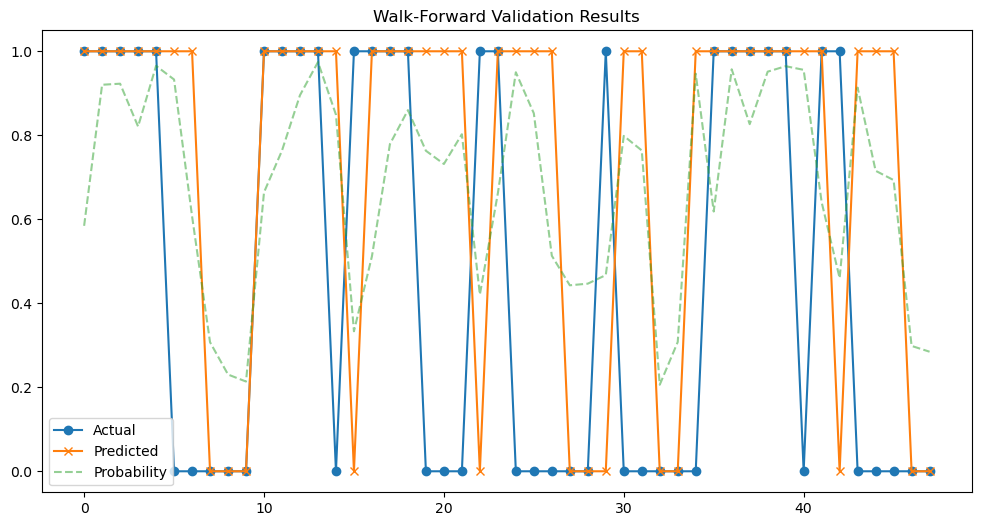

In [72]:
# Modify your main function to return the best parameters
def main():
    # Load data
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist()  # Get feature names for later use
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)
    
    # Phase 1: Hyperparameter tuning
    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params = tune_hyperparameters(X, y)  # Keep original function
    
    # Phase 2: Final evaluation
    print("\n=== PHASE 2: FINAL EVALUATION ===")
    actuals, preds, probs = walk_forward_validation(X, y, FINAL_TEST_POINTS, best_params)
    
    return best_params, feature_names, X, y

if __name__ == "__main__":
    best_params, feature_names, X, y = main()


Re-running CV for feature importance analysis...


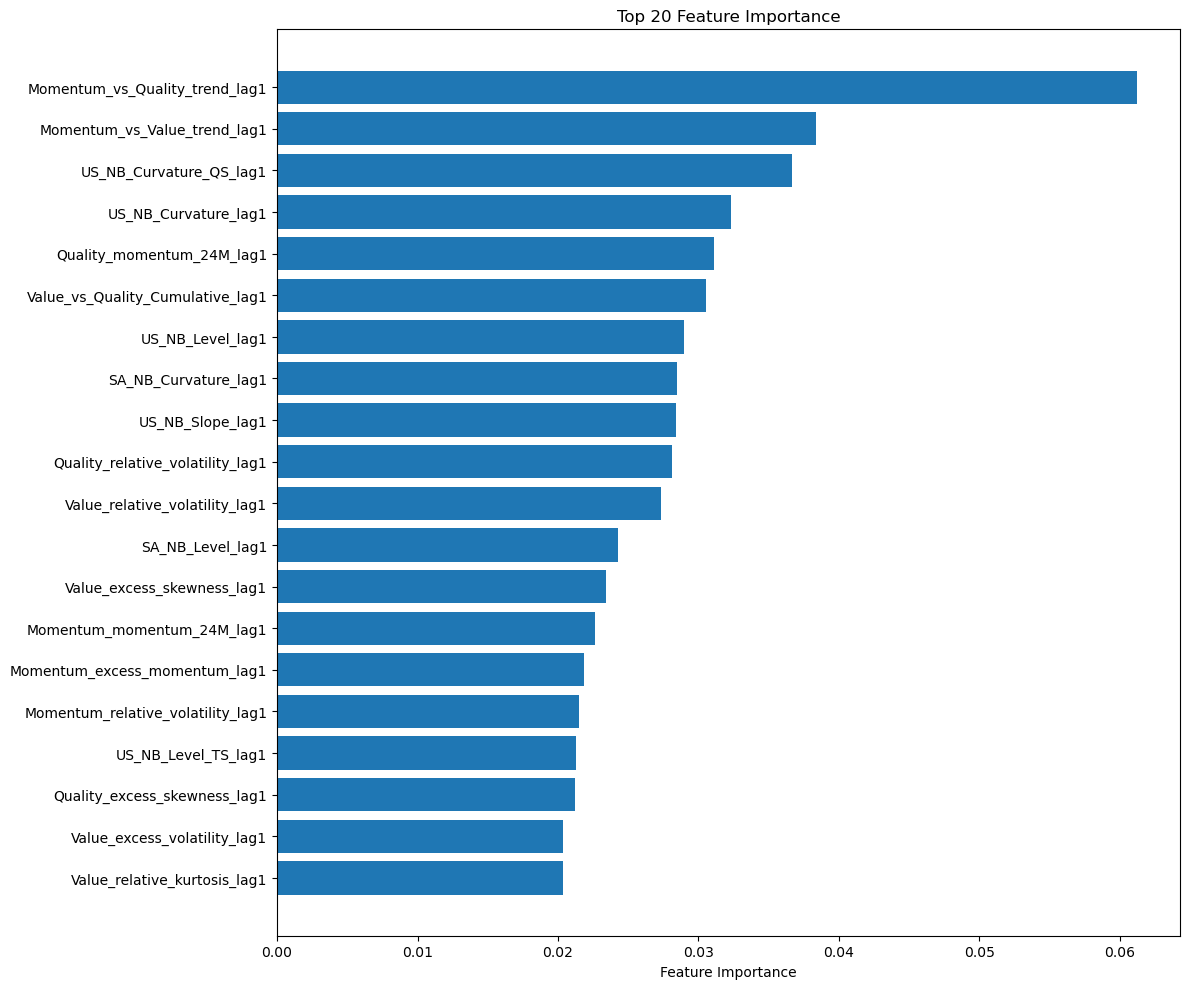


=== Top 20 Most Important Features ===
Momentum_vs_Quality_trend_lag1: 0.0612
Momentum_vs_Value_trend_lag1: 0.0384
US_NB_Curvature_QS_lag1: 0.0366
US_NB_Curvature_lag1: 0.0323
Quality_momentum_24M_lag1: 0.0311
Value_vs_Quality_Cumulative_lag1: 0.0305
US_NB_Level_lag1: 0.0290
SA_NB_Curvature_lag1: 0.0285
US_NB_Slope_lag1: 0.0284
Quality_relative_volatility_lag1: 0.0281
Value_relative_volatility_lag1: 0.0274
SA_NB_Level_lag1: 0.0242
Value_excess_skewness_lag1: 0.0234
Momentum_momentum_24M_lag1: 0.0227
Momentum_excess_momentum_lag1: 0.0219
Momentum_relative_volatility_lag1: 0.0215
US_NB_Level_TS_lag1: 0.0213
Quality_excess_skewness_lag1: 0.0212
Value_excess_volatility_lag1: 0.0204
Value_relative_kurtosis_lag1: 0.0204


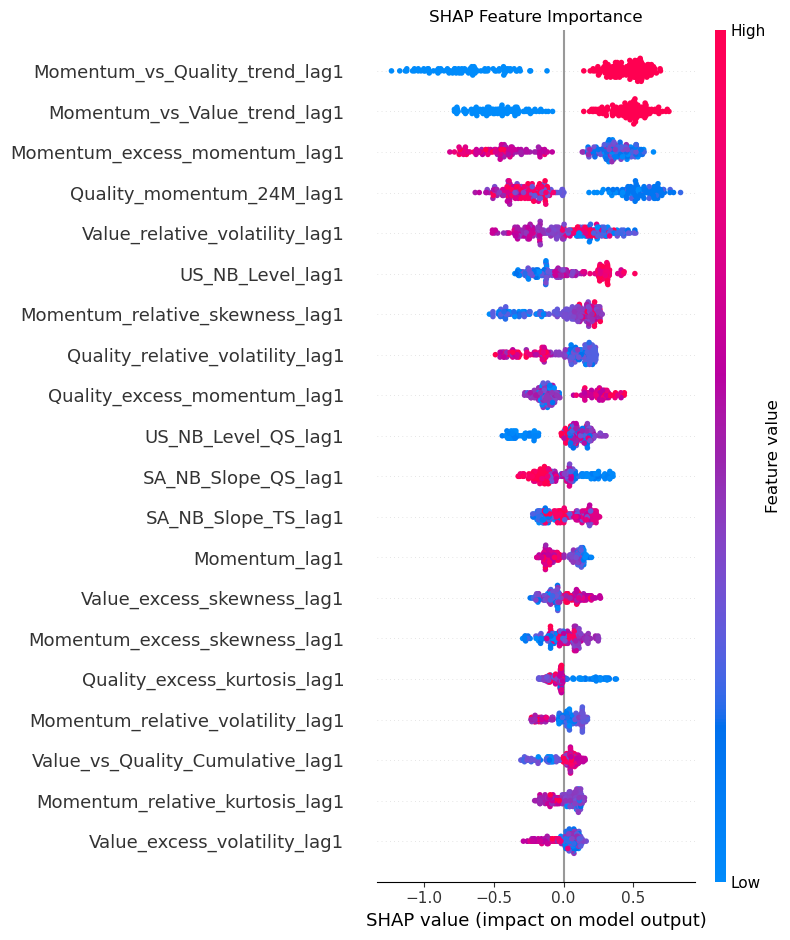


=== SHAP Feature Importance (Top 15) ===
Momentum_vs_Quality_trend_lag1: 0.5471
Momentum_vs_Value_trend_lag1: 0.4691
Momentum_excess_momentum_lag1: 0.4032
Quality_momentum_24M_lag1: 0.3882
Value_relative_volatility_lag1: 0.2129
US_NB_Level_lag1: 0.1935
Momentum_relative_skewness_lag1: 0.1873
Quality_relative_volatility_lag1: 0.1791
Quality_excess_momentum_lag1: 0.1774
US_NB_Level_QS_lag1: 0.1670
SA_NB_Slope_QS_lag1: 0.1405
SA_NB_Slope_TS_lag1: 0.1251
Momentum_lag1: 0.1048
Value_excess_skewness_lag1: 0.0993
Momentum_excess_skewness_lag1: 0.0952


In [73]:
# Analyze feature importance:
importance_df = analyze_feature_importance_afterwards(best_params, X, y, feature_names)
plot_feature_importance(importance_df)
shap_df = shap_analysis_afterwards(best_params, X, y, feature_names)